# Lightweight Processing + Visualization

This notebook demonstrates the lightweight streaming flow with a **declarative transform spec**.
You define transform rules, and the library executes them before analysis.


In [10]:
import sys
from datetime import date, timedelta
from pathlib import Path


def _find_project_src(start: Path) -> Path:
    # Prefer walking up from the current working directory.
    for base in [start, *start.parents]:
        candidate = base / "src" / "data_ingestion"
        if candidate.exists():
            return base / "src"

    # Explicit fallback: two directories up from cwd.
    two_up = start.parent.parent
    candidate = two_up / "src" / "data_ingestion"
    if candidate.exists():
        return two_up / "src"

    raise RuntimeError("Could not locate project src/data_ingestion from notebook cwd")


SRC_PATH = _find_project_src(Path.cwd().resolve())
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib.pyplot as plt
import pandas as pd

from data_ingestion.pipeline import stream_transformed_records

plt.style.use("ggplot")

In [11]:
# Keep date range small to minimize API usage.
end_date = date.today()
start_date = end_date - timedelta(days=7)

fetcher_specs = [
    {
        "source": "openalex",
        "config": {
            "query": "data engineering",
            "max_pages": 1,
            "per_page": 50,
        },
    },
    {
        "source": "crossref",
        "config": {
            "query": "data engineering",
            "max_pages": 1,
            "rows": 50,
        },
    },
]

transform_spec = {
    "transforms": [
        {"op": "require_fields", "fields": ["title", "url"]},
        {
            "op": "include_terms",
            "terms": ["data", "engineering", "pipeline", "etl"],
            "fields": ["title", "abstract", "topic"],
        },
        {"op": "dedupe", "keys": ["source", "external_id", "url"]},
    ]
}

rows = []
for source, record in stream_transformed_records(
    fetcher_specs,
    transform_spec=transform_spec,
    start_date=start_date.isoformat(),
    end_date=end_date.isoformat(),
):
    rows.append(
        {
            "source": source,
            "external_id": record.external_id,
            "title": record.title,
            "published_date": (
                record.published_date.isoformat()
                if record.published_date is not None
                else None
            ),
            "topic": record.topic,
        }
    )

df = pd.DataFrame(rows)
df.head()

2026-03-15 18:07:49,479 | INFO     | data_ingestion.pipeline | stream_records started raw=False specs=2 start_date=2026-03-08 end_date=2026-03-15 transforms_enabled=True
2026-03-15 18:07:49,481 | INFO     | data_ingestion.pipeline | Applying date overrides start_date=2026-03-08 end_date=2026-03-15 specs=2
2026-03-15 18:07:49,482 | INFO     | data_ingestion.factories | Built fetcher source=openalex class=OpenAlexFetcher
2026-03-15 18:07:49,483 | INFO     | data_ingestion.factories | Built fetcher source=crossref class=CrossRefFetcher
2026-03-15 18:07:49,483 | INFO     | data_ingestion.factories | Built 2 fetcher(s)
2026-03-15 18:07:49,894 | INFO     | data_ingestion.pipeline | stream_records source=openalex yielded_normalized=50
2026-03-15 18:07:50,368 | INFO     | data_ingestion.pipeline | stream_records source=crossref yielded_normalized=44


,source,external_id,title,published_date,topic
0,openalex,https://openalex.org/W4200065432,International Journal of Multimedia Data Engin...,2026-03-11,Image Retrieval and Classification Techniques
1,openalex,https://openalex.org/W4235929402,Applied Mechanics and Materials,2026-03-14,Material Properties and Applications
2,openalex,https://openalex.org/W76711023,Materials Science Forum,2026-03-12,Silicon Carbide Semiconductor Technologies
3,openalex,https://openalex.org/W2460119131,Defect and Diffusion Forum,2026-03-14,Advancements in Photolithography Techniques
4,openalex,https://openalex.org/W4232384861,Solid State Phenomena,2026-03-11,Materials science


In [12]:
print(f"Total rows: {len(df)}")
df["source"].value_counts()

Total rows: 94


source
openalex    50
crossref    44
Name: count, dtype: int64

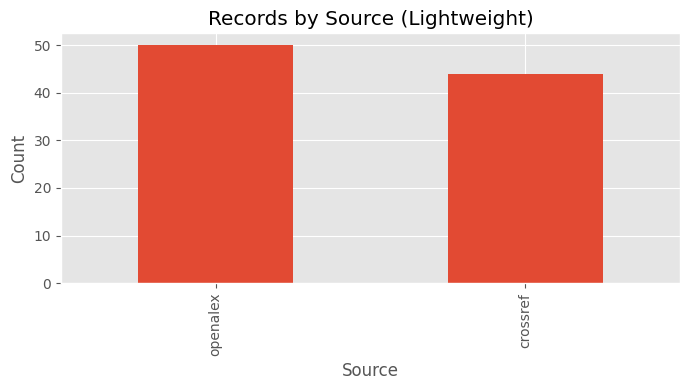

In [13]:
# Visualization 1: records by source
ax = (
    df["source"]
    .value_counts()
    .plot(kind="bar", figsize=(7, 4), title="Records by Source (Lightweight)")
)
ax.set_xlabel("Source")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

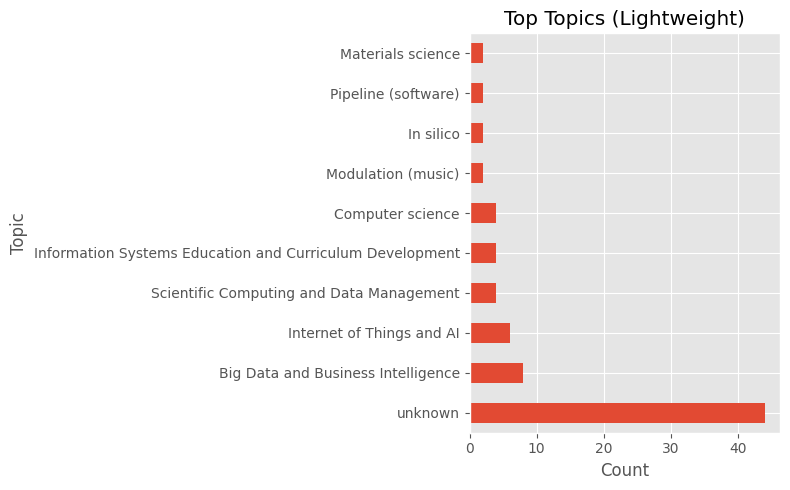

In [14]:
# Visualization 2: top topics from declarative transformation
top_topics = df["topic"].fillna("unknown").value_counts().head(10)
ax = top_topics.plot(kind="barh", figsize=(8, 5), title="Top Topics (Lightweight)")
ax.set_xlabel("Count")
ax.set_ylabel("Topic")
plt.tight_layout()
plt.show()

## Expanded Analysis

These additional checks help validate data quality, understand temporal behavior, and inspect term-level patterns in transformed outputs.


In [15]:
# Analysis 1: data quality snapshot
analysis_df = df.copy()
analysis_df["published_date"] = pd.to_datetime(
    analysis_df["published_date"], errors="coerce"
)

quality = pd.DataFrame(
    {
        "rows": [len(analysis_df)],
        "unique_sources": [analysis_df["source"].nunique(dropna=True)],
        "unique_external_ids": [analysis_df["external_id"].nunique(dropna=True)],
        "missing_title_pct": [analysis_df["title"].isna().mean() * 100],
        "missing_topic_pct": [analysis_df["topic"].isna().mean() * 100],
        "missing_published_date_pct": [
            analysis_df["published_date"].isna().mean() * 100
        ],
    }
)
quality

,rows,unique_sources,unique_external_ids,missing_title_pct,missing_topic_pct,missing_published_date_pct
0,94,2,94,0.0,46.808511,0.0


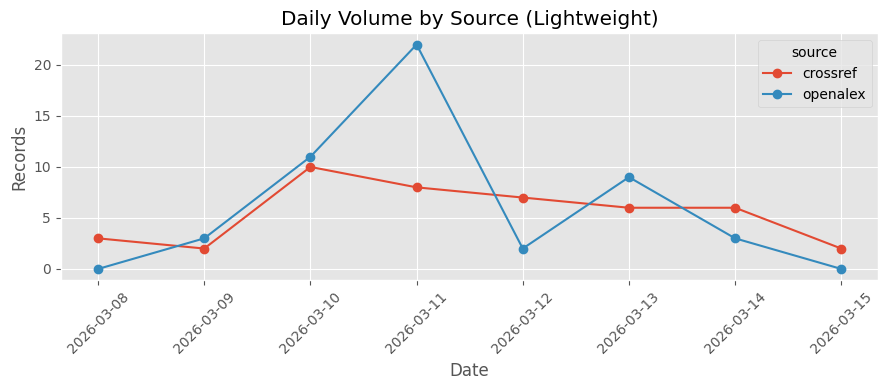

In [7]:
# Analysis 2: daily volume by source
daily_by_source = (
    analysis_df.dropna(subset=["published_date"])
    .groupby([analysis_df["published_date"].dt.date, "source"])
    .size()
    .unstack(fill_value=0)
)

if daily_by_source.empty:
    print("No valid published_date values available for daily trend analysis.")
else:
    ax = daily_by_source.plot(
        kind="line",
        marker="o",
        figsize=(9, 4),
        title="Daily Volume by Source (Lightweight)",
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Records")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

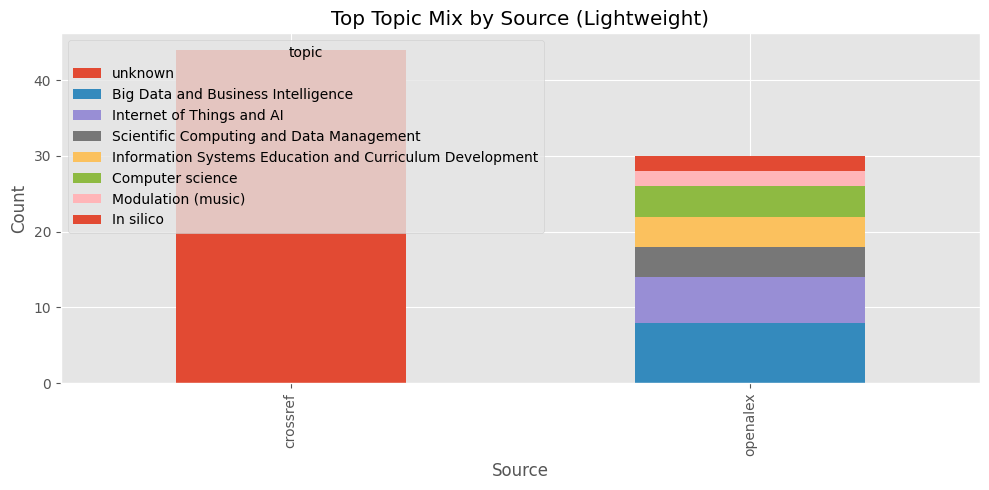

In [8]:
# Analysis 3: source-topic matrix (top topics)
top_topic_labels = analysis_df["topic"].fillna("unknown").value_counts().head(8).index
matrix = pd.crosstab(
    analysis_df["source"],
    analysis_df["topic"].fillna("unknown"),
)[top_topic_labels]

if matrix.empty:
    print("No source/topic data available for matrix analysis.")
else:
    ax = matrix.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5),
        title="Top Topic Mix by Source (Lightweight)",
    )
    ax.set_xlabel("Source")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

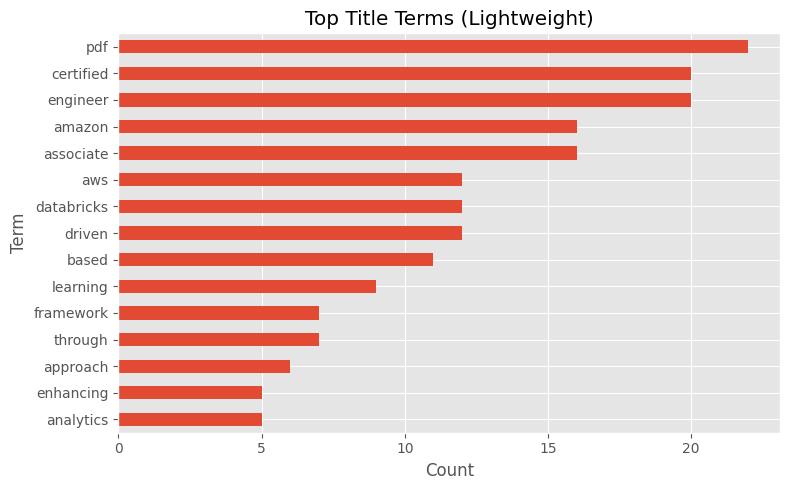

In [9]:
# Analysis 4: top terms in titles
stop_words = {
    "the",
    "and",
    "for",
    "with",
    "from",
    "into",
    "data",
    "engineering",
    "using",
    "study",
    "system",
    "analysis",
    "model",
    "models",
}
title_tokens = (
    analysis_df["title"].fillna("").str.lower().str.findall(r"[a-z]{3,}").explode()
)
title_tokens = title_tokens[title_tokens.notna() & ~title_tokens.isin(stop_words)]
top_terms = title_tokens.value_counts().head(15)

if top_terms.empty:
    print("No title token data available for term-frequency analysis.")
else:
    ax = top_terms.sort_values().plot(
        kind="barh",
        figsize=(8, 5),
        title="Top Title Terms (Lightweight)",
    )
    ax.set_xlabel("Count")
    ax.set_ylabel("Term")
    plt.tight_layout()
    plt.show()